<a href="https://colab.research.google.com/github/Kaveesha-Vihanga/DS_Project/blob/component-1/arrival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
!pip install prophet xgboost -q


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/DSGP/monthlyarrivals_clean.xlsx')

In [ ]:
country_map = {
    "USA": "United States",
    "United States": "United States",
    'United states': 'United States',
    'united states': 'United States',
    'UK': 'United Kingdom',
    'Russia': 'Russian Federation',
    'india': 'India',
    'china': 'China',
    'france': 'France',
    'spain': 'Spain',
    'ukraine': 'Ukraine',
    'canada': 'Canada',
    'others': 'Others',
    'Kazakhastan': 'Kazakhstan'

}

# Apply mapping
df['Nationality'] = df['Nationality'].replace(country_map)


In [ ]:
#Clean column names
df.columns = df.columns.str.strip()

#Remove commas inside numbers
df = df.replace(",", "", regex=True)
df["Arrivals"] = pd.to_numeric(df["Arrivals"])

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         1452 non-null   int64  
 1   Month        1452 non-null   object 
 2   Nationality  1452 non-null   object 
 3   Arrivals     1452 non-null   int64  
 4   Avg_Stay     1452 non-null   float64
 5   Revenue_USD  1452 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 68.2+ KB


In [ ]:
df.shape


(1452, 6)

In [ ]:
df.columns

Index(['Year', 'Month', 'Nationality', 'Arrivals', 'Avg_Stay', 'Revenue_USD'], dtype='object')

In [ ]:
df.dtypes

,0
Year,int64
Month,object
Nationality,object
Arrivals,int64
Avg_Stay,float64
Revenue_USD,float64


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Nationality,0
Arrivals,0
Avg_Stay,0
Revenue_USD,0


In [ ]:
#Encode months
month_map = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

df["Month_Num"] = df["Month"].map(month_map)

In [ ]:
df.head()

,Year,Month,Nationality,Arrivals,Avg_Stay,Revenue_USD,Month_Num
0,2015,January,Australia,6825,10.4,8517600.0,1
1,2015,January,China,4741,6.9,3925548.0,1
2,2015,January,France,5087,11.2,6836928.0,1
3,2015,January,Germany,5800,12.0,8352000.0,1
4,2015,January,India,32175,5.3,20463300.0,1


In [ ]:
df = df.sort_values(["Nationality", "Year", "Month_Num"]).reset_index(drop=True)

In [ ]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month_Num"].astype(str) + "-01"
)


In [ ]:
df['COVID_Dummy'] = 0
df.loc[
    (df['Date'] >= '2020-03-01') & (df['Date'] <= '2021-12-01'),
    'COVID_Dummy'
] = 1

print("Nationalities after cleaning:", sorted(df['Nationality'].unique()))
print("Shape:", df.shape)
print("COVID rows:", df['COVID_Dummy'].sum())

Nationalities after cleaning: ['Australia', 'China', 'France', 'Germany', 'India', 'Maldives', 'Netherlands', 'Others', 'Russian Federation', 'United Kingdom', 'United States']
Shape: (1452, 9)
COVID rows: 242


In [ ]:
#metrics
from sklearn.metrics import mean_squared_error

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    # Avoid division by zero for months with 0 arrivals (COVID months)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_results = []
sarima_forecasts = {}

for nat in df['Nationality'].unique():
    series = df[df['Nationality'] == nat].set_index('Date')['Arrivals']

    if len(series) < 36:
        continue

    train = series[:-12]
    test  = series[-12:]

    model = SARIMAX(
        train,
        order=(1, 1, 1),           # AR=1, differencing=1, MA=1
        seasonal_order=(1, 1, 1, 12),  # seasonal period = 12 months
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred = model.forecast(12).clip(lower=0)

    sarima_results.append({
        'Nationality': nat,
        'SARIMA_RMSE': rmse(test, pred),
        'SARIMA_MAPE': mape(test, pred)
    })
    sarima_forecasts[nat] = pred

sarima_df = pd.DataFrame(sarima_results)
print(sarima_df.sort_values('SARIMA_MAPE'))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

           Nationality  SARIMA_RMSE  SARIMA_MAPE
4                India  4396.894944     9.789970
7               Others  8191.409949    12.263354
10       United States   741.766893    12.425040
6          Netherlands   679.040734    13.210836
2               France  1322.584825    15.037817
0            Australia  1531.284779    17.783120
9       United Kingdom  4197.035673    25.028687
5             Maldives  1143.653551    30.047141
3              Germany  3912.966544    34.090811
8   Russian Federation  6254.168333    43.829909
1                China  5964.849432    55.527856


In [ ]:
sarimax_results = []
sarimax_forecasts = {}

for nat in df['Nationality'].unique():
    temp   = df[df['Nationality'] == nat].set_index('Date')
    y      = temp['Arrivals']
    exog   = temp[['COVID_Dummy']]

    if len(y) < 36:
        continue

    y_train     = y[:-12]
    y_test      = y[-12:]
    exog_train  = exog[:-12]
    exog_test   = exog[-12:]

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred = model.forecast(12, exog=exog_test).clip(lower=0)

    sarimax_results.append({
        'Nationality': nat,
        'SARIMAX_RMSE': rmse(y_test, pred),
        'SARIMAX_MAPE': mape(y_test, pred),
        'COVID_Coefficient': round(model.params['COVID_Dummy'], 2)
    })
    sarimax_forecasts[nat] = {'model': model, 'pred': pred}

sarimax_df = pd.DataFrame(sarimax_results)
print(sarimax_df.sort_values('SARIMAX_MAPE'))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

           Nationality  SARIMAX_RMSE  SARIMAX_MAPE  COVID_Coefficient
10       United States    494.478776      4.084030           -2021.57
0            Australia    839.316028      6.440724           -3015.77
2               France    788.913501      6.683494           -3243.32
4                India   4154.906117      9.335107           -8615.50
9       United Kingdom   1742.443992      9.562937           -7055.75
7               Others   8447.358577     12.751508            2265.00
6          Netherlands    736.576119     14.385114            -740.57
5             Maldives    625.549369     16.474577           -2227.57
3              Germany   1957.687768     16.843367           -5502.25
8   Russian Federation   3254.301824     22.943619          -15298.98
1                China   6030.997308     56.158947            -427.00


In [ ]:
from prophet import Prophet

prophet_results = []
prophet_forecasts = {}

for nat in df['Nationality'].unique():
    temp = df[df['Nationality'] == nat][['Date', 'Arrivals', 'COVID_Dummy']].copy()
    temp = temp.rename(columns={'Date': 'ds', 'Arrivals': 'y'})

    if len(temp) < 36:
        continue

    train = temp[:-12].copy()
    test  = temp[-12:].copy()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # we have monthly data, not daily
        daily_seasonality=False,
        seasonality_mode='multiplicative'  # better for tourism (peaks are proportional)
    )
    model.add_regressor('COVID_Dummy')
    model.fit(train)

    # Future dataframe must include COVID_Dummy column
    future = model.make_future_dataframe(periods=12, freq='MS')
    future = future.merge(
        temp[['ds', 'COVID_Dummy']], on='ds', how='left'
    )
    future['COVID_Dummy'] = future['COVID_Dummy'].fillna(0)

    forecast = model.predict(future)
    pred = forecast['yhat'][-12:].values.clip(min=0)

    prophet_results.append({
        'Nationality': nat,
        'Prophet_RMSE': rmse(test['y'].values, pred),
        'Prophet_MAPE': mape(test['y'].values, pred)
    })
    prophet_forecasts[nat] = {'model': model, 'pred': pred}

prophet_df = pd.DataFrame(prophet_results)
print(prophet_df.sort_values('Prophet_MAPE'))

           Nationality  Prophet_RMSE  Prophet_MAPE
6          Netherlands    183.883555      3.245148
10       United States    371.953667      4.429747
3              Germany   1072.375895      8.802676
5             Maldives    614.079176     12.938764
2               France   1299.083349     13.114976
9       United Kingdom   3281.041819     16.595266
0            Australia   1923.496230     18.506244
8   Russian Federation   3617.575459     23.791427
1                China   3558.665575     32.090855
4                India  18137.844559     39.202469
7               Others  39160.340967     60.347585


In [ ]:
from xgboost import XGBRegressor

def make_lag_features(sub_df):
    """Create lag and rolling features for ML models."""
    s = sub_df.copy().sort_values('Date').reset_index(drop=True)
    s['lag_1']   = s['Arrivals'].shift(1)
    s['lag_2']   = s['Arrivals'].shift(2)
    s['lag_3']   = s['Arrivals'].shift(3)
    s['lag_12']  = s['Arrivals'].shift(12)   # same month last year
    s['lag_24']  = s['Arrivals'].shift(24)   # same month 2 years ago
    s['roll_3']  = s['Arrivals'].shift(1).rolling(3).mean()
    s['roll_6']  = s['Arrivals'].shift(1).rolling(6).mean()
    s['roll_12'] = s['Arrivals'].shift(1).rolling(12).mean()
    for m in range(1, 13):
        s[f'month_{m}'] = (s['Month_Num'] == m).astype(int)
    s['COVID_Dummy'] = sub_df['COVID_Dummy'].values
    s['year'] = s['Year']
    return s

feature_cols = (
    ['lag_1','lag_2','lag_3','lag_12','lag_24','roll_3','roll_6','roll_12','COVID_Dummy','year']
    + [f'month_{m}' for m in range(1, 13)]
)

xgb_results = []
xgb_forecasts = {}
xgb_models = {}

for nat in df['Nationality'].unique():
    sub = df[df['Nationality'] == nat].copy()

    if len(sub) < 36:
        continue

    sub = make_lag_features(sub)
    sub = sub.dropna(subset=feature_cols).reset_index(drop=True)

    train = sub[sub['Year'] < 2024]
    test  = sub[sub['Year'] == 2024]

    if len(train) < 20 or len(test) == 0:
        continue

    model = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    )
    model.fit(train[feature_cols], train['Arrivals'])
    pred = model.predict(test[feature_cols]).clip(min=0)

    xgb_results.append({
        'Nationality': nat,
        'XGB_RMSE': rmse(test['Arrivals'].values, pred),
        'XGB_MAPE': mape(test['Arrivals'].values, pred)
    })
    xgb_forecasts[nat] = pred
    xgb_models[nat] = model

xgb_df = pd.DataFrame(xgb_results)
print(xgb_df.sort_values('XGB_MAPE'))

           Nationality      XGB_RMSE   XGB_MAPE
5             Maldives    223.777966   4.255046
4                India   5523.982802   9.189491
9       United Kingdom   2444.079274  12.977065
0            Australia   1344.309674  14.721471
10       United States    843.861511  15.833185
7               Others  16881.920270  17.253025
3              Germany   2274.065083  18.083943
2               France   2267.994158  28.954249
8   Russian Federation   4960.757200  30.355243
1                China   4146.724973  36.356459
6          Netherlands   1716.953989  38.666087


In [ ]:
# Merge all results into one comparison table
final_df = (
    sarima_df
    .merge(sarimax_df[['Nationality','SARIMAX_RMSE','SARIMAX_MAPE','COVID_Coefficient']], on='Nationality', how='left')
    .merge(prophet_df[['Nationality','Prophet_RMSE','Prophet_MAPE']], on='Nationality', how='left')
    .merge(xgb_df[['Nationality','XGB_RMSE','XGB_MAPE']], on='Nationality', how='left')
)


# Pick best model per nationality based on lowest MAPE
mape_cols = {
    'SARIMA':       'SARIMA_MAPE',
    'SARIMAX':      'SARIMAX_MAPE',
    'Prophet':      'Prophet_MAPE',
    'XGBoost':      'XGB_MAPE'
}

def get_best_model(row):
    scores = {name: row[col] for name, col in mape_cols.items()
              if pd.notna(row[col])}
    return min(scores, key=scores.get)

def get_best_mape(row):
    scores = {name: row[col] for name, col in mape_cols.items()
              if pd.notna(row[col])}
    return round(min(scores.values()), 2)

final_df['Best_Model'] = final_df.apply(get_best_model, axis=1)
final_df['Best_MAPE']  = final_df.apply(get_best_mape, axis=1)

# Round for display
for col in ['SARIMA_MAPE','SARIMAX_MAPE','Prophet_MAPE','XGB_MAPE']:
    final_df[col] = final_df[col].round(2)

print("=" * 70)
print("MODEL COMPARISON — MAPE % (lower = better)")
print("=" * 70)
display_cols = ['Nationality','SARIMA_MAPE','SARIMAX_MAPE',
                'Prophet_MAPE','XGB_MAPE','Best_Model','Best_MAPE']
print(final_df[display_cols].to_string(index=False))

print("\n\nAVERAGE MAPE PER MODEL:")
for name, col in mape_cols.items():
    avg = final_df[col].mean()
    print(f"  {name:<20}: {avg:.2f}%")

MODEL COMPARISON — MAPE % (lower = better)
       Nationality  SARIMA_MAPE  SARIMAX_MAPE  Prophet_MAPE  XGB_MAPE Best_Model  Best_MAPE
         Australia        17.78          6.44         18.51     14.72    SARIMAX       6.44
             China        55.53         56.16         32.09     36.36    Prophet      32.09
            France        15.04          6.68         13.11     28.95    SARIMAX       6.68
           Germany        34.09         16.84          8.80     18.08    Prophet       8.80
             India         9.79          9.34         39.20      9.19    XGBoost       9.19
          Maldives        30.05         16.47         12.94      4.26    XGBoost       4.26
       Netherlands        13.21         14.39          3.25     38.67    Prophet       3.25
            Others        12.26         12.75         60.35     17.25     SARIMA      12.26
Russian Federation        43.83         22.94         23.79     30.36    SARIMAX      22.94
    United Kingdom        25.03      

In [ ]:
# Exclude COVID years for seasonality — they distort the true pattern
non_covid = df[~df['Year'].isin([2020, 2021])]

months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

print("PEAK MONTH PER NATIONALITY (avg monthly arrivals, excl. COVID)")
print("-" * 50)

seasonality_results = {}

for nat in sorted(df['Nationality'].unique()):
    nat_data = non_covid[non_covid['Nationality'] == nat]
    monthly_avg = nat_data.groupby('Month')['Arrivals'].mean()
    monthly_avg = monthly_avg.reindex(months_order)

    peak_month   = monthly_avg.idxmax()
    low_month    = monthly_avg.idxmin()
    peak_val     = int(monthly_avg.max())
    low_val      = int(monthly_avg.min())
    seasonality_index = (monthly_avg / monthly_avg.mean() * 100).round(1)

    seasonality_results[nat] = {
        'peak_month': peak_month,
        'low_month': low_month,
        'monthly_avg': monthly_avg,
        'seasonality_index': seasonality_index
    }

    print(f"{nat:<25} Peak: {peak_month:<12} ({peak_val:>7,})  |  Low: {low_month:<12} ({low_val:>7,})")

PEAK MONTH PER NATIONALITY (avg monthly arrivals, excl. COVID)
--------------------------------------------------
Australia                 Peak: December     ( 10,719)  |  Low: June         (  4,729)
China                     Peak: February     ( 10,153)  |  Low: May          (  5,801)
France                    Peak: December     ( 10,242)  |  Low: May          (  5,287)
Germany                   Peak: December     ( 15,814)  |  Low: January      (  7,229)
India                     Peak: December     ( 42,194)  |  Low: June         ( 24,111)
Maldives                  Peak: December     (  5,430)  |  Low: May          (  2,715)
Netherlands               Peak: July         (  3,759)  |  Low: January      (  2,013)
Others                    Peak: December     (109,262)  |  Low: May          ( 53,069)
Russian Federation        Peak: February     ( 17,676)  |  Low: June         (  8,207)
United Kingdom            Peak: December     ( 22,666)  |  Low: May          ( 10,666)
United States   

In [ ]:
def forecast_for_year(nationality, target_year):
    """
    Forecast monthly arrivals for a given nationality up to target_year.
    Uses the best model identified for that nationality.
    """
    last_data_year = df['Year'].max()  # 2025
    months_ahead   = (target_year - last_data_year) * 12

    if months_ahead <= 0:
        print(f"Target year must be after {last_data_year}")
        return None

    if nationality not in final_df['Nationality'].values:
        print(f"{nationality} not in model results")
        return None

    best_model = final_df[final_df['Nationality'] == nationality]['Best_Model'].values[0]
    print(f"Using {best_model} for {nationality} → forecasting {months_ahead} months ahead to {target_year}")

    series = df[df['Nationality'] == nationality].set_index('Date')['Arrivals']

    if best_model == 'Prophet':
        model_data = prophet_forecasts[nationality]['model']
        temp = df[df['Nationality'] == nationality][['Date','Arrivals','COVID_Dummy']].copy()
        temp = temp.rename(columns={'Date':'ds','Arrivals':'y'})
        # Refit on full data
        full_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative'
        )
        full_model.add_regressor('COVID_Dummy')
        full_model.fit(temp)
        future = full_model.make_future_dataframe(periods=months_ahead, freq='MS')
        future['COVID_Dummy'] = 0  # no COVID in future
        fc = full_model.predict(future)
        forecast_vals = fc['yhat'][-months_ahead:].clip(lower=0).values
        lower = fc['yhat_lower'][-months_ahead:].clip(lower=0).values
        upper = fc['yhat_upper'][-months_ahead:].values

    elif best_model in ['SARIMA', 'SARIMAX']:
      exog_full = df[df['Nationality'] == nationality].set_index('Date')[['COVID_Dummy']]
      future_exog = pd.DataFrame(
          {'COVID_Dummy': [0] * months_ahead},
          index=pd.date_range(start=series.index[-1] + pd.DateOffset(months=1),
                              periods=months_ahead, freq='MS')
      )
      full_model = SARIMAX(
          series,
          exog=exog_full if best_model == 'SARIMAX' else None,
          order=(1,1,1),
          seasonal_order=(1,1,1,12),
          enforce_stationarity=False,
          enforce_invertibility=False
      ).fit(disp=False)
      forecast_vals = full_model.forecast(
          months_ahead,
          exog=future_exog if best_model == 'SARIMAX' else None
      ).clip(lower=0).values
      lower = forecast_vals * 0.85
      upper = forecast_vals * 1.15

    else:  # XGBoost — recursive forecast
        history = df[df['Nationality'] == nationality].copy()
        history = make_lag_features(history).dropna(subset=feature_cols)
        model   = xgb_models[nationality]
        hist_arrivals = history['Arrivals'].tolist()
        forecast_vals = []
        last_year, last_month = last_data_year, 12

        for i in range(months_ahead):
            next_month = (last_month % 12) + 1
            next_year  = last_year + (1 if next_month == 1 else 0)
            last_month = next_month
            last_year  = next_year

            lag1  = hist_arrivals[-1]  if len(hist_arrivals) >= 1  else 0
            lag2  = hist_arrivals[-2]  if len(hist_arrivals) >= 2  else 0
            lag3  = hist_arrivals[-3]  if len(hist_arrivals) >= 3  else 0
            lag12 = hist_arrivals[-12] if len(hist_arrivals) >= 12 else 0
            lag24 = hist_arrivals[-24] if len(hist_arrivals) >= 24 else 0
            r3    = np.mean(hist_arrivals[-3:])
            r6    = np.mean(hist_arrivals[-6:])
            r12   = np.mean(hist_arrivals[-12:])
            row   = ([lag1,lag2,lag3,lag12,lag24,r3,r6,r12,0,next_year]
                     + [1 if m == next_month else 0 for m in range(1,13)])
            pred_val = max(0, model.predict(np.array(row).reshape(1,-1))[0])
            forecast_vals.append(pred_val)
            hist_arrivals.append(pred_val)

        forecast_vals = np.array(forecast_vals)
        lower = forecast_vals * 0.85
        upper = forecast_vals * 1.15

    # Build result dataframe
    future_dates = pd.date_range(
        start=pd.Timestamp(f'{last_data_year+1}-01-01'),
        periods=months_ahead, freq='MS'
    )
    result_df = pd.DataFrame({
        'Date':       future_dates,
        'Year':       future_dates.year,
        'Month':      future_dates.strftime('%B'),
        'Nationality': nationality,
        'Forecast':   forecast_vals.astype(int),
        'Lower_CI':   lower.astype(int),
        'Upper_CI':   upper.astype(int),
        'Model_Used': best_model
    })

    # Filter to only target year
    result_df = result_df[result_df['Year'] == target_year]
    return result_df

# Test it
result = forecast_for_year('India', 2030)
print(result)

Using XGBoost for India → forecasting 60 months ahead to 2030
         Date  Year      Month Nationality  Forecast  Lower_CI  Upper_CI  \
48 2030-01-01  2030    January       India     42576     36190     48963   
49 2030-02-01  2030   February       India     36298     30854     41743   
50 2030-03-01  2030      March       India     37879     32197     43561   
51 2030-04-01  2030      April       India     42730     36320     49139   
52 2030-05-01  2030        May       India     31625     26881     36369   
53 2030-06-01  2030       June       India     26171     22245     30097   
54 2030-07-01  2030       July       India     24131     20511     27751   
55 2030-08-01  2030     August       India     24403     20742     28063   
56 2030-09-01  2030  September       India     24665     20965     28365   
57 2030-10-01  2030    October       India     24769     21053     28484   
58 2030-11-01  2030   November       India     32648     27751     37545   
59 2030-12-01  2030   Dece

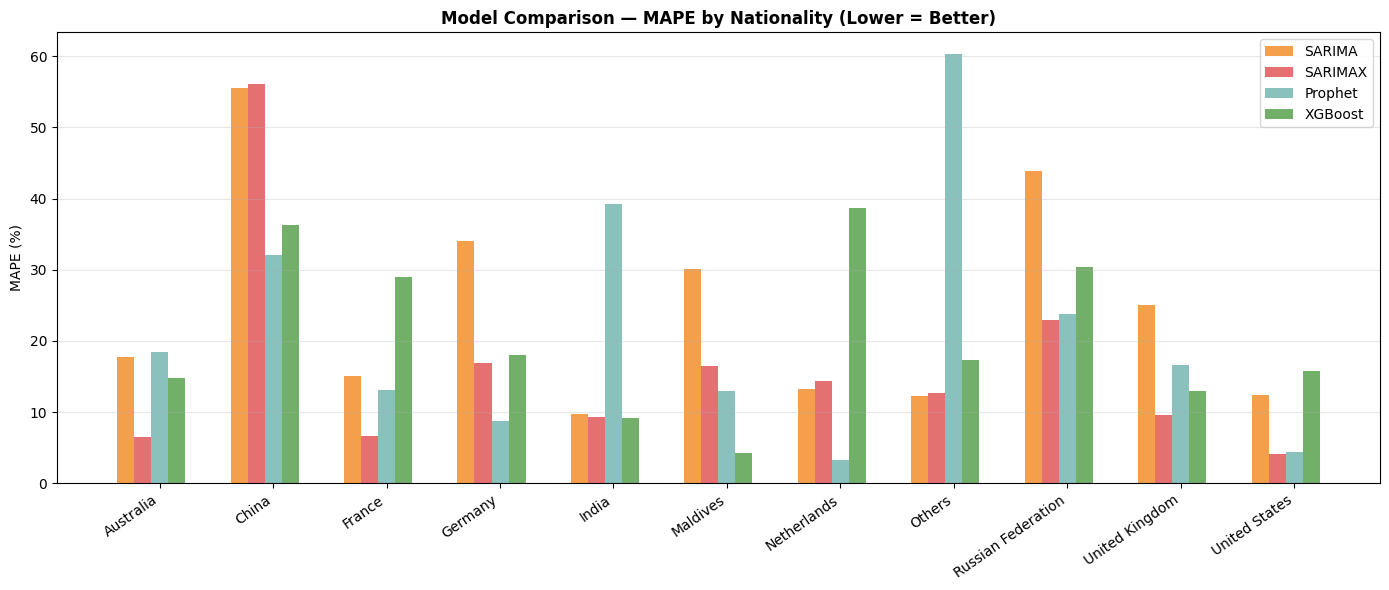

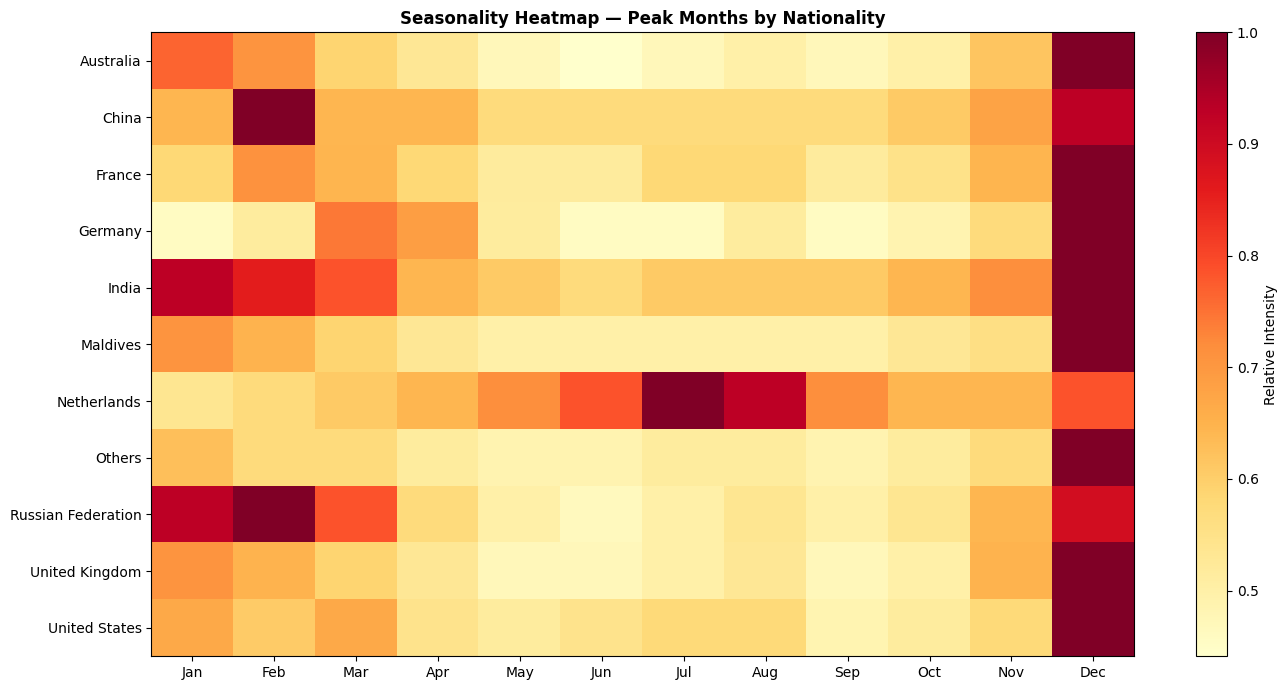

Using XGBoost for India → forecasting 24 months ahead to 2027


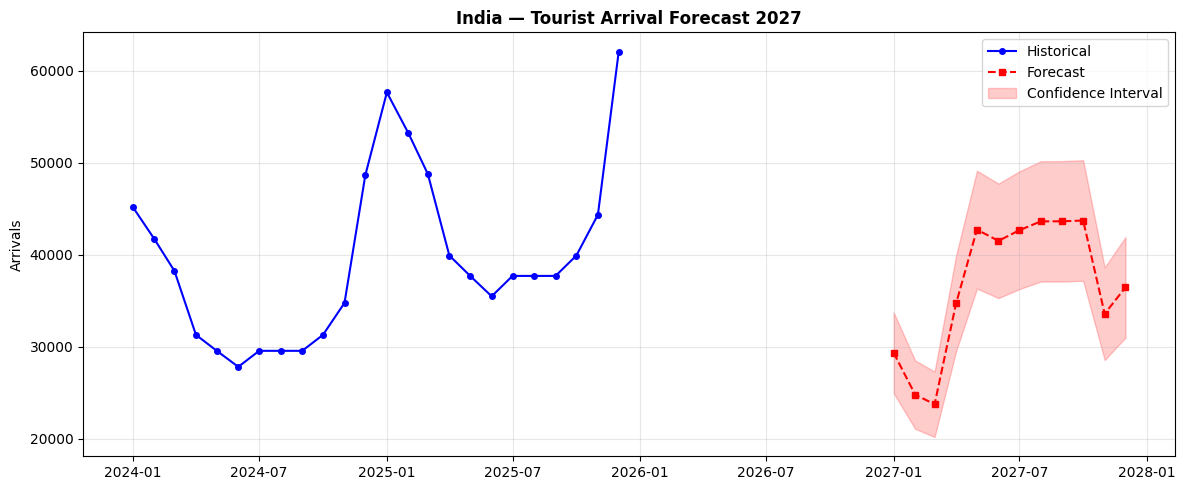

In [ ]:
# Plot 1: Model comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
mape_data = final_df.set_index('Nationality')[
    ['SARIMA_MAPE','SARIMAX_MAPE','Prophet_MAPE','XGB_MAPE']
].clip(upper=100)

x = np.arange(len(mape_data))
w = 0.15
colors = ['#f28e2b','#e15759','#76b7b2','#59a14f']
labels = ['SARIMA','SARIMAX','Prophet','XGBoost']

for i, (col, color, label) in enumerate(zip(mape_data.columns, colors, labels)):
    ax.bar(x + i*w, mape_data[col], w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + w*2)
ax.set_xticklabels(mape_data.index, rotation=35, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('Model Comparison — MAPE by Nationality (Lower = Better)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Seasonality heatmap
pivot = non_covid.groupby(['Nationality','Month'])['Arrivals'].mean().unstack()
pivot = pivot.reindex(columns=months_order)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot_norm.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in months_order])
ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index)
ax.set_title('Seasonality Heatmap — Peak Months by Nationality', fontweight='bold')
plt.colorbar(im, label='Relative Intensity')
plt.tight_layout()
plt.show()

# Plot 3: Forecast for a specific nationality
result = forecast_for_year('India', 2027)
plt.figure(figsize=(12, 5))
hist = df[df['Nationality']=='India'].set_index('Date')['Arrivals']
plt.plot(hist.index[-24:], hist.values[-24:], 'b-o', label='Historical', markersize=4)
plt.plot(pd.to_datetime(result['Date']), result['Forecast'], 'r--s', label='Forecast', markersize=5)
plt.fill_between(pd.to_datetime(result['Date']),
                 result['Lower_CI'], result['Upper_CI'],
                 alpha=0.2, color='red', label='Confidence Interval')
plt.title('India — Tourist Arrival Forecast 2027', fontweight='bold')
plt.ylabel('Arrivals')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("AVERAGE METRICS PER MODEL")
print("=" * 60)
print(f"{'Model':<15} {'Avg RMSE':>12} {'Avg MAPE %':>12}")
print("-" * 60)
print(f"{'SARIMA':<15} {sarima_df['SARIMA_RMSE'].mean():>12.0f} {sarima_df['SARIMA_MAPE'].mean():>11.2f}%")
print(f"{'SARIMAX':<15} {sarimax_df['SARIMAX_RMSE'].mean():>12.0f} {sarimax_df['SARIMAX_MAPE'].mean():>11.2f}%")
print(f"{'Prophet':<15} {prophet_df['Prophet_RMSE'].mean():>12.0f} {prophet_df['Prophet_MAPE'].mean():>11.2f}%")
print(f"{'XGBoost':<15} {xgb_df['XGB_RMSE'].mean():>12.0f} {xgb_df['XGB_MAPE'].mean():>11.2f}%")

print("\n")
print("=" * 60)
print("BEST MODEL PER NATIONALITY")
print("=" * 60)
print(final_df[['Nationality','Best_Model','Best_MAPE']].to_string(index=False))
print("-" * 60)
print(f"{'Overall Average MAPE':<30} {final_df['Best_MAPE'].mean():.2f}%")

AVERAGE METRICS PER MODEL
Model               Avg RMSE   Avg MAPE %
------------------------------------------------------------
SARIMA                  3485       24.46%
SARIMAX                 2643       15.97%
Prophet                 6656       21.19%
XGBoost                 3875       20.60%


BEST MODEL PER NATIONALITY
       Nationality Best_Model  Best_MAPE
         Australia    SARIMAX       6.44
             China    Prophet      32.09
            France    SARIMAX       6.68
           Germany    Prophet       8.80
             India    XGBoost       9.19
          Maldives    XGBoost       4.26
       Netherlands    Prophet       3.25
            Others     SARIMA      12.26
Russian Federation    SARIMAX      22.94
    United Kingdom    SARIMAX       9.56
     United States    SARIMAX       4.08
------------------------------------------------------------
Overall Average MAPE           10.87%
